# Car Price Prediction Using Machine Learning

**Student:** Aditya Vishwakarma  
**Target:** estimate a used vehicle's selling price from year, present price, kilometres driven, fuel, seller type, transmission and owner count. Prices in the included dataset are in INR lakh.

This beginner-friendly project compares two regression pipelines using a held-out test set.

## Problem Statement

Used-car values depend on vehicle details and market conditions. Buyers and sellers can find it difficult to set a reasonable price. This project learns patterns from historical listings and estimates a selling price from available features. The estimate is a learning aid, not a substitute for vehicle inspection or current market research.

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
RANDOM_STATE=42
FIGURE_DIR=Path('figures'); FIGURE_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\hp\\AppData\\Local\\matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## Load Dataset

The notebook expects the accompanying `car_data.csv` in this folder, so no absolute path or internet connection is needed at run time. The source uses `Seller_Type`; we rename it `Selling_Type` for clarity.

In [2]:
df=pd.read_csv('car_data.csv')
if 'Seller_Type' in df and 'Selling_Type' not in df: df=df.rename(columns={'Seller_Type':'Selling_Type'})
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Selling_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Data Understanding

`Year` is the model year; `Present_Price` is the listed reference/ex-showroom value; `Kms_Driven` is distance in kilometres; `Fuel_Type`, `Selling_Type`, and `Transmission` are categories; `Owner` counts previous owners; and `Selling_Price` is the target in INR lakh. `Car_Name` is excluded from this compact model to focus on the requested features.

In [3]:
print('Shape:',df.shape)
display(df.head())
display(df.dtypes.to_frame('Data type'))
display(df.describe(include='all').T)
df.info()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Selling_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


,Data type
Car_Name,str
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,str
Selling_Type,str
Transmission,str
Owner,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_Type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


## Data Cleaning

Check missing and duplicate records. Remove exact duplicates and retain the target plus requested predictors. Convert numeric columns explicitly and discard rows with invalid target values. Missing predictor values are imputed within the training pipeline, so statistics are learned only from training rows.

In [4]:
print('Missing before cleaning:',df.isna().sum())
print('Duplicates:',df.duplicated().sum())
df=df.drop_duplicates().copy()
feature_cols=['Year','Present_Price','Kms_Driven','Fuel_Type','Selling_Type','Transmission','Owner']
target='Selling_Price'
for col in ['Year','Present_Price','Kms_Driven','Owner',target]: df[col]=pd.to_numeric(df[col],errors='coerce')
df=df.dropna(subset=[target])[feature_cols+[target]].copy()
print('Cleaned shape:',df.shape)
print('Missing after cleaning:',df.isna().sum())

Missing before cleaning: Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Selling_Type     0
Transmission     0
Owner            0
dtype: int64
Duplicates: 2
Cleaned shape: (299, 8)
Missing after cleaning: Year             0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Selling_Type     0
Transmission     0
Owner            0
Selling_Price    0
dtype: int64


## Exploratory Data Analysis

These plots show associations in a small historical dataset; they do not prove that one feature causes a price change.

### Distribution of Selling Price

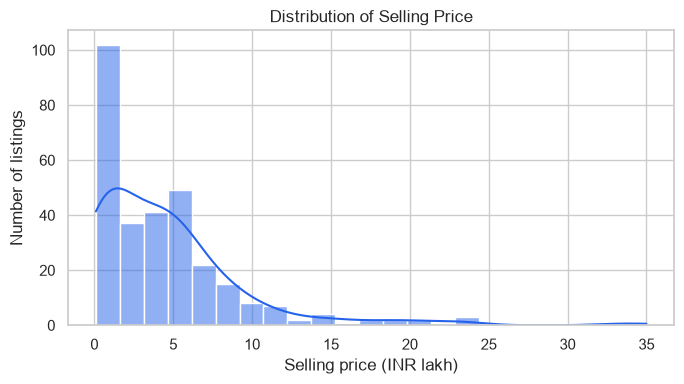

In [5]:
fig,ax=plt.subplots(figsize=(7,4))
sns.histplot(df['Selling_Price'],kde=True,ax=ax,color='#2563eb')
ax.set(title='Distribution of Selling Price',xlabel='Selling price (INR lakh)',ylabel='Number of listings')
fig.tight_layout(); fig.savefig(FIGURE_DIR/'selling_price_distribution.png',dpi=160); plt.show()

### Selling Price vs Model Year

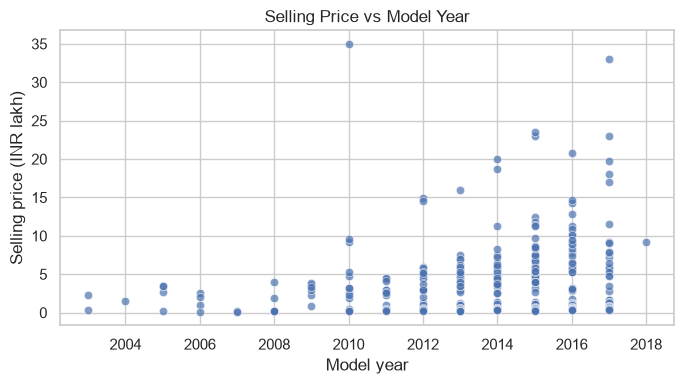

In [6]:
fig,ax=plt.subplots(figsize=(7,4))
sns.scatterplot(data=df,x='Year',y='Selling_Price',alpha=.7,ax=ax)
ax.set(title='Selling Price vs Model Year',xlabel='Model year',ylabel='Selling price (INR lakh)')
fig.tight_layout(); fig.savefig(FIGURE_DIR/'price_vs_year.png',dpi=160); plt.show()

### Selling Price vs Present Price

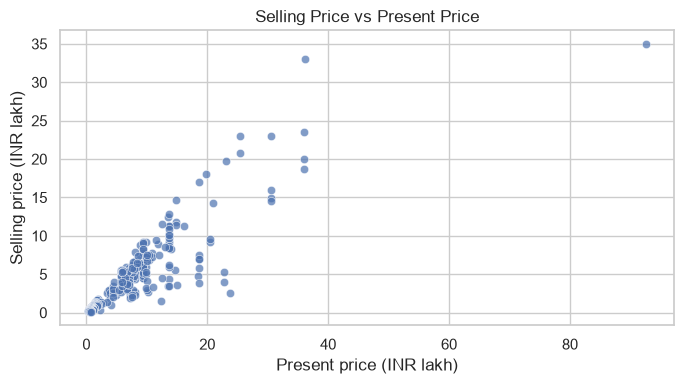

In [7]:
fig,ax=plt.subplots(figsize=(7,4))
sns.scatterplot(data=df,x='Present_Price',y='Selling_Price',alpha=.7,ax=ax)
ax.set(title='Selling Price vs Present Price',xlabel='Present price (INR lakh)',ylabel='Selling price (INR lakh)')
fig.tight_layout(); fig.savefig(FIGURE_DIR/'price_vs_present_price.png',dpi=160); plt.show()

### Selling Price vs Kilometres Driven

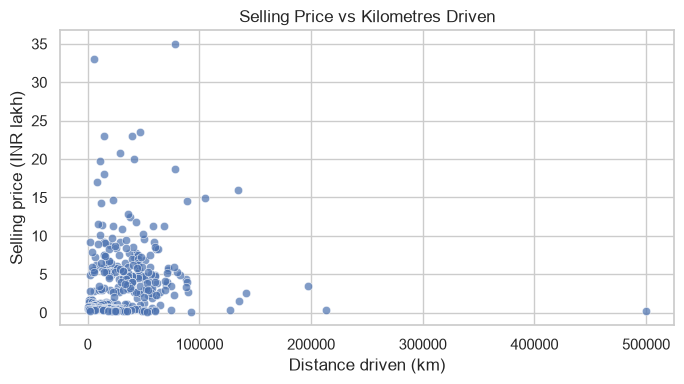

In [8]:
fig,ax=plt.subplots(figsize=(7,4))
sns.scatterplot(data=df,x='Kms_Driven',y='Selling_Price',alpha=.7,ax=ax)
ax.set(title='Selling Price vs Kilometres Driven',xlabel='Distance driven (km)',ylabel='Selling price (INR lakh)')
fig.tight_layout(); fig.savefig(FIGURE_DIR/'price_vs_kms.png',dpi=160); plt.show()

### Selling Price by Fuel Type

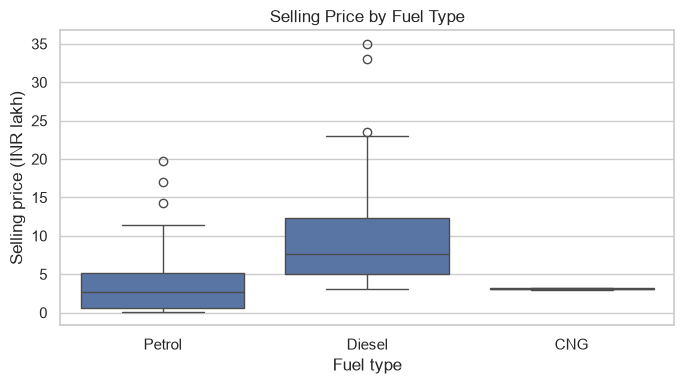

In [9]:
fig,ax=plt.subplots(figsize=(7,4))
sns.boxplot(data=df,x='Fuel_Type',y='Selling_Price',ax=ax)
ax.set(title='Selling Price by Fuel Type',xlabel='Fuel type',ylabel='Selling price (INR lakh)')
fig.tight_layout(); fig.savefig(FIGURE_DIR/'price_by_fuel.png',dpi=160); plt.show()

### Selling Price by Transmission

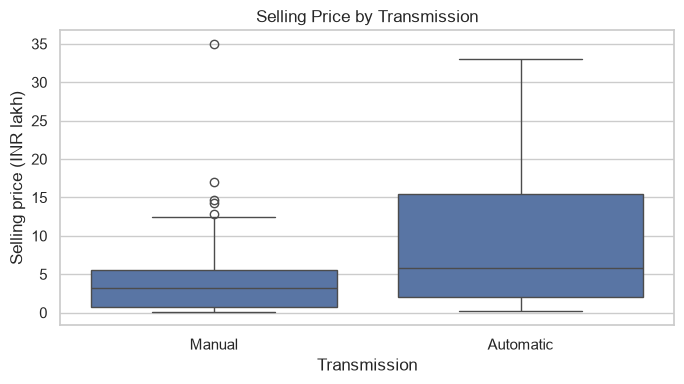

In [10]:
fig,ax=plt.subplots(figsize=(7,4))
sns.boxplot(data=df,x='Transmission',y='Selling_Price',ax=ax)
ax.set(title='Selling Price by Transmission',xlabel='Transmission',ylabel='Selling price (INR lakh)')
fig.tight_layout(); fig.savefig(FIGURE_DIR/'price_by_transmission.png',dpi=160); plt.show()

## Data Preprocessing

Split rows before fitting preprocessing. Numeric fields use median imputation; categorical fields use most-frequent imputation and one-hot encoding. Unknown categories at prediction time are safely ignored. Keeping preprocessing in the pipeline prevents test-set leakage.

In [11]:
X=df[feature_cols]; y=df[target]
numeric=['Year','Present_Price','Kms_Driven','Owner']; categorical=['Fuel_Type','Selling_Type','Transmission']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=42)
def make_preprocessor():
    return ColumnTransformer([('num',SimpleImputer(strategy='median'),numeric),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),categorical)])
print('Training rows:',len(X_train),'Test rows:',len(X_test))

Training rows: 239 Test rows: 60


## Model Training

Selling price is a continuous value, so this is regression. Linear Regression is an interpretable baseline. Random Forest averages decision trees and can capture nonlinear patterns.

In [12]:
models={'Linear Regression':Pipeline([('prep',make_preprocessor()),('model',LinearRegression())]),'Random Forest':Pipeline([('prep',make_preprocessor()),('model',RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1))])}
rows=[]; predictions={}
for name,model in models.items():
    model.fit(X_train,y_train); pred=model.predict(X_test); predictions[name]=pred
    rows.append({'Model':name,'MAE':mean_absolute_error(y_test,pred),'MSE':mean_squared_error(y_test,pred),'RMSE':np.sqrt(mean_squared_error(y_test,pred)),'R2 Score':r2_score(y_test,pred)})
results_df=pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
display(results_df.round(4))

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.4729,6.3708,2.5240,0.7528
1,Random Forest,1.4971,12.7285,3.5677,0.5061


## Model Evaluation and Selection

MAE is mean absolute error; MSE squares errors and penalizes large misses; RMSE is in lakh rupees; R² compares against predicting the test-set mean. We select the lowest-RMSE pipeline on the held-out test set. With just 301 historical listings, results are indicative rather than a guarantee for today's market.

In [13]:
best_name=results_df.loc[0,'Model']; best_model=models[best_name]; y_pred=predictions[best_name]
print('Selected model:',best_name)
print(results_df.iloc[0].to_dict())

Selected model: Linear Regression
{'Model': 'Linear Regression', 'MAE': 1.4728924140032085, 'MSE': 6.3707529568267915, 'RMSE': 2.5240350545954766, 'R2 Score': 0.7528154215831553}


## Actual vs Predicted

Points near the diagonal are close to their actual held-out values; points farther away are larger errors.

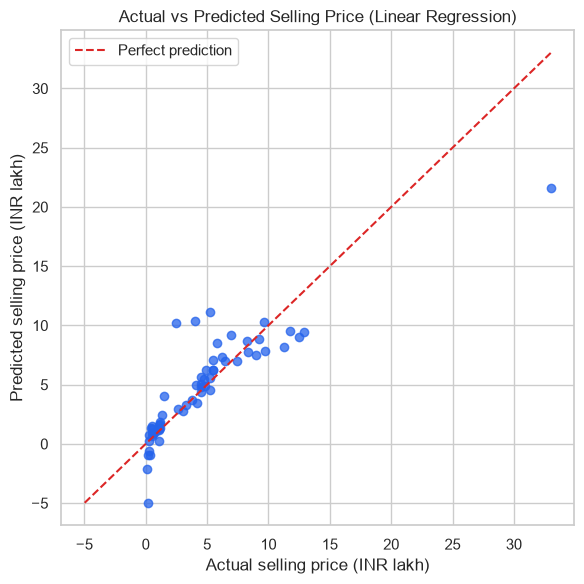

In [14]:
fig,ax=plt.subplots(figsize=(6,6)); ax.scatter(y_test,y_pred,alpha=.75,color='#2563eb')
lims=[min(y_test.min(),y_pred.min()),max(y_test.max(),y_pred.max())]
ax.plot(lims,lims,'--',color='#dc2626',label='Perfect prediction')
ax.set(title=f'Actual vs Predicted Selling Price ({best_name})',xlabel='Actual selling price (INR lakh)',ylabel='Predicted selling price (INR lakh)'); ax.legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR/'actual_vs_predicted.png',dpi=160); plt.show()

## Feature Importance

Random Forest importance is impurity-based. For Linear Regression, absolute coefficients are shown. These describe the fitted model and are not causal effects.

,Feature,Importance
5,cat__Fuel_Type_Diesel,1.195867
4,cat__Fuel_Type_CNG,0.943244
9,cat__Transmission_Automatic,0.786063
10,cat__Transmission_Manual,0.786063
8,cat__Selling_Type_Individual,0.650688
7,cat__Selling_Type_Dealer,0.650688
3,num__Owner,0.642856
1,num__Present_Price,0.437187
0,num__Year,0.331041
6,cat__Fuel_Type_Petrol,0.252622


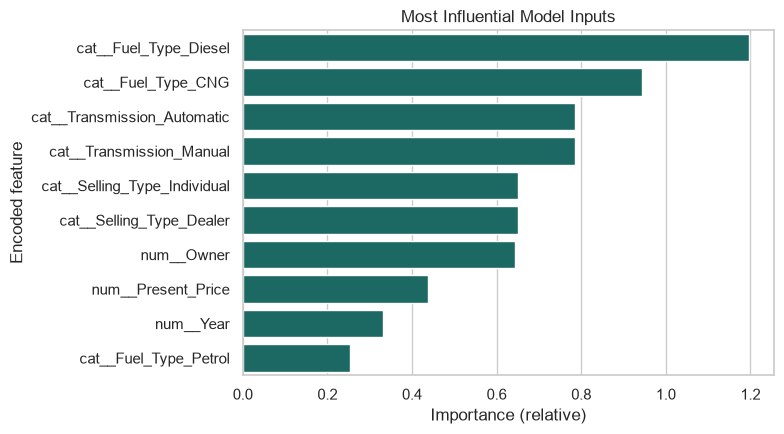

In [15]:
prep=best_model.named_steps['prep']; estimator=best_model.named_steps['model']
feature_names=prep.get_feature_names_out()
importance=estimator.feature_importances_ if hasattr(estimator,'feature_importances_') else np.abs(np.ravel(estimator.coef_))
importance_df=pd.DataFrame({'Feature':feature_names,'Importance':importance}).sort_values('Importance',ascending=False).head(10)
display(importance_df)
fig,ax=plt.subplots(figsize=(8,4.5)); sns.barplot(data=importance_df,x='Importance',y='Feature',ax=ax,color='#0f766e')
ax.set(title='Most Influential Model Inputs',xlabel='Importance (relative)',ylabel='Encoded feature'); fig.tight_layout()
fig.savefig(FIGURE_DIR/'feature_importance.png',dpi=160); plt.show()

## Sample Prediction

Edit the values to explore other cases. Prediction is expressed in INR lakh.

In [16]:
sample_car=pd.DataFrame({'Year':[2015],'Present_Price':[8.0],'Kms_Driven':[30000],'Fuel_Type':['Petrol'],'Selling_Type':['Dealer'],'Transmission':['Manual'],'Owner':[0]})
sample_prediction=best_model.predict(sample_car)[0]
print(f'Estimated selling price: INR {sample_prediction:.2f} lakh')

Estimated selling price: INR 5.29 lakh


## Save Model

The complete pipeline is saved, including imputation and encoding. Load it with `joblib.load("car_price_model.pkl")`.

In [17]:
joblib.dump(best_model,'car_price_model.pkl')
print('Saved complete pipeline to car_price_model.pkl')

Saved complete pipeline to car_price_model.pkl


## Conclusion

The workflow cleans the included CarDekho-based data, explores price patterns, and compares a linear baseline with a tree ensemble. The lowest-RMSE pipeline is selected for the sample estimate. Reference price, year, distance driven, fuel, transmission, seller channel and owner count provide useful information. More representative recent data and independent validation would improve confidence.

## Future Scope

- Add recent listings and condition/location information.
- Tune hyperparameters with cross-validation.
- Compare gradient boosting or XGBoost.
- Build a Streamlit interface for interactive estimates.